# 31 - LSEG/Gemma sector-neutral capped exact-extrema spread

**Question.** Does return-blind sector neutralisation preserve or improve the
first strategy-quality pass from Notebook 30, or was that result partly a
sector-dollar bet?

This is an **iterative, retrospective factor-control audit** on the already
opened 2025-2026 LSEG window. The frozen baseline is Notebook 30's exact
Gemma +1/-1 spread with a 25% maximum name weight. The challenger subtracts
the equal-weight mean target inside each of the 11 frozen four-company
sectors, then applies one common scale only if gross exposure would exceed
100% or a name would exceed 25%. It never scales up, fits a coefficient, or
changes the signal, horizon, session set, sector map, cap, or cost.

Two alternatives fail before returns are considered: the local scheduled
earnings calendar ends in 2023, before this panel begins, and an exact +1/-1
match within the same sector has fewer than the predeclared 60 active
sessions. These availability checks are recorded below rather than silently
discarded.

At 10 bps per traded side, the **policy-selection gate** requires
sector-neutral net Sharpe at least 0.10 above the capped baseline, paired
net-return non-inferiority at -1 bp/session, break-even above 10 bps/side, and
nonnegative sector-neutral Sharpe in both chronological halves. A separate
**risk-control gate** requires the same return non-inferiority, lower maximum
drawdown, and a BH-significant reduction in downside-squared loss. The
**standalone quality gate** retains Notebook 30's >=60 active sessions, net
Sharpe >=0.75, <=25% name weight, break-even above cost, and nonnegative half
Sharpes, while adding exact sector-dollar neutrality. The strict **alpha
gate** still requires the sector-neutral return interval versus cash to
exclude zero. Net return and downside-squared loss form one two-outcome
paired family; attribution, equal-weight-market exposure, and leave-one-out
results are diagnostics, not selectors.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sector_portfolios import (  # noqa: E402
    SECTOR_BY_SYMBOL,
    SECTOR_MEMBERS,
    validate_sector_map,
)
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
    sector_neutralize_targets,
)
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402

SEED = 20260806
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
GROSS_EXPOSURE = 1.0
SINGLE_NAME_CAP = 0.25
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0
ARMS = ("capacity_capped", "sector_neutral")

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
NOTEBOOK30_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread/manifest.json"
)
EARNINGS_PATH = (
    REPO_ROOT
    / "final_experiments/data/earnings"
    / "fnspid_earnings_calendar_2011_2023_quarterly.csv"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/31_lseg_gemma_sector_neutral_extrema_spread"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Data, provenance, and exact return reproduction

Only the aggregate firm-open panel, price opens, and the calendar's date
column are loaded. No licensed headline or earnings-title text is displayed
or persisted. Split-adjusted open returns must exactly reproduce Notebook 13.

In [2]:
validate_sector_map()
gemma = pd.read_parquet(GEMMA_PATH)
gemma["session_date"] = pd.to_datetime(gemma["session_date"]).dt.normalize()
gemma["sector"] = gemma["symbol"].map(SECTOR_BY_SYMBOL)
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")
if gemma["sector"].isna().any():
    raise ValueError("Gemma symbols do not match the frozen sector map")

open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if len(symbols) != 44 or open_wide.shape[1] != 44:
    raise ValueError("expected the fixed 44-company population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(44).all():
    raise ValueError("Gemma panel must contain all 44 firms on every session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("Gemma sessions must be consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed_raw_open_h1": float(value)}
        )
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    how="left",
    validate="1:1",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")
coverage = pd.DataFrame(
    [
        {
            "firm_open_rows": len(gemma),
            "sessions": len(sessions),
            "companies": len(symbols),
            "sectors": gemma["sector"].nunique(),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

,firm_open_rows,sessions,companies,sectors,first_entry_session,last_entry_session,last_return_end,max_return_reproduction_error
0,7348,167,44,11,2025-10-27,2026-06-26,2026-06-29,0.000000


## Return-blind feasibility screen and frozen target construction

The calendar-overlap and exact same-sector-match checks use dates and signals
only. The sector-neutral challenger begins from the exact capped baseline,
subtracts each sector mean from all four constituents, and only scales down.

In [3]:
capped_targets, capped_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=1,
    single_name_cap=SINGLE_NAME_CAP,
)
neutral_targets, neutral_audit = sector_neutralize_targets(
    capped_targets,
    sector_by_symbol=SECTOR_BY_SYMBOL,
    gross_exposure=GROSS_EXPOSURE,
    single_name_cap=SINGLE_NAME_CAP,
)

exact = gemma.loc[gemma["strongest_event"].isin([-1.0, 1.0])]
same_sector_counts = (
    exact.groupby(["session_date", "sector"])["strongest_event"]
    .agg(positive=lambda values: int(values.eq(1.0).sum()), negative=lambda values: int(values.eq(-1.0).sum()))
)
same_sector_active = same_sector_counts.loc[
    same_sector_counts["positive"].gt(0) & same_sector_counts["negative"].gt(0)
].index.get_level_values("session_date").nunique()
earnings_dates = pd.read_csv(EARNINGS_PATH, usecols=["report_date"], parse_dates=["report_date"])
earnings_overlap = int(
    earnings_dates["report_date"].between(sessions.min(), sessions.max()).sum()
)
candidate_feasibility = pd.DataFrame(
    [
        {
            "candidate": "scheduled_earnings_conditioning",
            "available_sessions": earnings_overlap,
            "minimum_sessions": MINIMUM_ACTIVE_SESSIONS,
            "viable": earnings_overlap >= MINIMUM_ACTIVE_SESSIONS,
            "reason": f"calendar ends {earnings_dates['report_date'].max().date()}",
        },
        {
            "candidate": "exact_within_sector_sign_match",
            "available_sessions": same_sector_active,
            "minimum_sessions": MINIMUM_ACTIVE_SESSIONS,
            "viable": same_sector_active >= MINIMUM_ACTIVE_SESSIONS,
            "reason": "requires exact +1 and -1 in the same four-company sector",
        },
        {
            "candidate": "sector_demeaned_capped_spread",
            "available_sessions": int(capped_audit["eligible"].sum()),
            "minimum_sessions": MINIMUM_ACTIVE_SESSIONS,
            "viable": int(capped_audit["eligible"].sum()) >= MINIMUM_ACTIVE_SESSIONS,
            "reason": "uses all globally two-sided exact-event sessions",
        },
    ]
)

base_active = capped_audit["eligible"].to_numpy(dtype=bool)
neutral_active = neutral_audit["neutral_gross_exposure"].gt(0).to_numpy(dtype=bool)
if not np.array_equal(base_active, neutral_active):
    raise RuntimeError("sector neutralisation changed the active-session set")
if neutral_audit["neutral_max_abs_sector_exposure"].max() > 1e-12:
    raise RuntimeError("sector-neutral target retains sector-dollar exposure")
if neutral_audit["neutral_max_name_weight"].max() > SINGLE_NAME_CAP + 1e-12:
    raise RuntimeError("sector-neutral target violates the frozen name cap")
if max(abs(target.net_exposure) for target in neutral_targets) > 1e-12:
    raise RuntimeError("sector-neutral targets are not dollar-neutral")

active_neutral = neutral_audit.loc[neutral_active]
construction_audit = pd.DataFrame(
    [
        {
            "sessions": len(capped_audit),
            "active_sessions": int(base_active.sum()),
            "sessions_with_hedges": int(neutral_audit["hedge_names"].gt(0).sum()),
            "capped_mean_gross_exposure": float(capped_audit["gross_exposure"].mean()),
            "neutral_mean_gross_exposure": float(neutral_audit["neutral_gross_exposure"].mean()),
            "neutral_mean_active_gross_exposure": float(active_neutral["neutral_gross_exposure"].mean()),
            "capped_max_name_weight": float(capped_audit["max_abs_name_weight"].max()),
            "neutral_max_name_weight": float(neutral_audit["neutral_max_name_weight"].max()),
            "capped_max_abs_sector_exposure": float(
                neutral_audit["base_max_abs_sector_exposure"].max()
            ),
            "neutral_max_abs_sector_exposure": float(
                neutral_audit["neutral_max_abs_sector_exposure"].max()
            ),
            "neutral_mean_active_names": float(active_neutral["active_names"].mean()),
            "neutral_mean_hedge_names": float(active_neutral["hedge_names"].mean()),
            "neutral_mean_hedge_gross": float(
                active_neutral["hedge_gross_after_neutralization"].mean()
            ),
            "scaled_down_sessions": int(neutral_audit["scale_multiplier"].lt(1.0 - 1e-12).sum()),
        }
    ]
)
display(candidate_feasibility)
display(construction_audit.T)

,candidate,available_sessions,minimum_sessions,viable,reason
0,scheduled_earnings_conditioning,0,60,False,calendar ends 2023-12-21
1,exact_within_sector_sign_match,9,60,False,requires exact +1 and -1 in the same four-comp...
2,sector_demeaned_capped_spread,80,60,True,uses all globally two-sided exact-event sessions


,0
sessions,167.000000
active_sessions,80.000000
sessions_with_hedges,78.000000
capped_mean_gross_exposure,0.281437
neutral_mean_gross_exposure,0.371407
neutral_mean_active_gross_exposure,0.775313
capped_max_name_weight,0.250000
neutral_max_name_weight,0.250000
capped_max_abs_sector_exposure,0.500000
neutral_max_abs_sector_exposure,0.000000


## Drift-aware ledger and exact Notebook 30 reproduction

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one final liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    intervals["downside_sq"] = np.minimum(intervals["net_return"], 0.0) ** 2
    return intervals


def run_targets(
    target_rows: tuple,
    return_values: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ledger = run_open_to_open_ledger(
        target_rows,
        return_values,
        cost_rate_per_side=cost_bps / 10_000.0,
        initial_nav_usd=INITIAL_NAV,
        force_final_liquidation=True,
    )
    full = ledger_rows_to_frame(ledger)
    return fold_final_liquidation(full), full


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    peaks = np.maximum.accumulate(with_start)
    turnover_sum = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(np.mean(gross)),
        "mean_net": float(np.mean(net)),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / peaks - 1.0)),
        "mean_turnover": float(turnover_sum / len(daily)),
        "total_turnover": turnover_sum,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "mean_active_names": float(daily.loc[daily["gross_exposure"].gt(0), "active_names"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover_sum),
        "cost_bps_per_side": cost_bps,
    }


target_paths = {
    "capacity_capped": capped_targets,
    "sector_neutral": neutral_targets,
}
daily_paths: dict[str, pd.DataFrame] = {}
ledger_paths: dict[str, pd.DataFrame] = {}
for arm in ARMS:
    daily_paths[arm], ledger_paths[arm] = run_targets(
        target_paths[arm], return_rows, cost_bps=COST_BPS
    )
results = pd.DataFrame(
    [{"arm": arm, **summarize_path(daily_paths[arm], cost_bps=COST_BPS)} for arm in ARMS]
)

notebook30 = json.loads(NOTEBOOK30_MANIFEST.read_text())
reference = pd.DataFrame(notebook30["results"]).set_index("arm").loc["capacity_capped"]
reproduced = results.set_index("arm").loc["capacity_capped"]
reproduction_metrics = (
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_gross",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
    "breakeven_bps_per_side",
)
for metric in reproduction_metrics:
    if not np.isclose(float(reproduced[metric]), float(reference[metric]), atol=1e-10):
        raise RuntimeError(f"Notebook 30 reproduction failed for {metric}")
reproduction = pd.DataFrame(
    [
        {
            "metrics_checked": len(reproduction_metrics),
            "all_match_within_1e_10": True,
            "reference_notebook": "30_lseg_gemma_capped_extrema_spread.ipynb",
        }
    ]
)
display(results.T)
display(reproduction)

,0,1
arm,capacity_capped,sector_neutral
n_sessions,167,167
active_sessions,80,80
mean_gross,0.001049,0.000166
mean_net,0.000597,-0.000414
sharpe_gross,2.945235,0.735738
sharpe_net,1.696870,-1.857059
ann_vol_net,0.088723,0.056230
total_return_gross,0.188166,0.026943
total_return_net,0.102037,-0.067848


,metrics_checked,all_match_within_1e_10,reference_notebook
0,9,True,30_lseg_gemma_capped_extrema_spread.ipynb


## Return-loss decomposition

This arithmetic decomposition is descriptive and was added after seeing the
frozen gate result. It separates the challenger-minus-baseline net-return gap
into the gross-return component removed by sector demeaning and the extra
cost created by the wider hedge book. It does not add another hypothesis test.

In [5]:
result_index_for_decomposition = results.set_index("arm")
baseline_row = result_index_for_decomposition.loc["capacity_capped"]
neutral_row = result_index_for_decomposition.loc["sector_neutral"]
gross_difference = float(neutral_row["mean_gross"] - baseline_row["mean_gross"])
baseline_cost = float(baseline_row["mean_gross"] - baseline_row["mean_net"])
neutral_cost = float(neutral_row["mean_gross"] - neutral_row["mean_net"])
incremental_cost = neutral_cost - baseline_cost
net_difference = float(neutral_row["mean_net"] - baseline_row["mean_net"])
mechanism_decomposition = pd.DataFrame(
    [
        {
            "neutral_minus_capped_gross_bps_session": gross_difference * 10_000,
            "neutral_minus_capped_incremental_cost_bps_session": incremental_cost * 10_000,
            "neutral_minus_capped_net_bps_session": net_difference * 10_000,
            "absolute_net_gap_share_from_removed_gross": float(
                abs(gross_difference) / abs(net_difference)
            ),
            "absolute_net_gap_share_from_incremental_cost": float(
                abs(incremental_cost) / abs(net_difference)
            ),
        }
    ]
)
display(mechanism_decomposition.T)

,0
neutral_minus_capped_gross_bps_session,-8.831656
neutral_minus_capped_incremental_cost_bps_session,1.286340
neutral_minus_capped_net_bps_session,-10.117997
absolute_net_gap_share_from_removed_gross,0.872866
absolute_net_gap_share_from_incremental_cost,0.127134


## Paired return, downside, and standalone-alpha inference

Positive paired estimates favour sector neutralisation. Downside is coded as
capped minus sector-neutral so an improvement is positive. BH is applied once
across the two policy outcomes. The cash comparison is a separate alpha gate.

In [6]:
inference_rows = []
for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
    if outcome == "net_return":
        challenger = daily_paths["sector_neutral"]
        baseline = daily_paths["capacity_capped"]
    else:
        challenger = daily_paths["capacity_capped"]
        baseline = daily_paths["sector_neutral"]
    estimate = paired_block_bootstrap_difference(
        challenger,
        baseline,
        value_col=outcome,
        block_length=BLOCK_LENGTH,
        replications=REPLICATIONS,
        seed=SEED + outcome_offset,
    )
    inference_rows.append(
        {"outcome": outcome, "positive_favours_sector_neutral": True, **estimate}
    )
paired_inference = pd.DataFrame(inference_rows)
paired_inference["bh_reject_q05"] = benjamini_hochberg(
    paired_inference["p_two_sided"].tolist(), q=0.05
)
cash = daily_paths["sector_neutral"][["session_date"]].copy()
cash["net_return"] = 0.0
neutral_vs_cash = pd.DataFrame(
    [
        {
            "comparison": "sector_neutral_minus_cash",
            **paired_block_bootstrap_difference(
                daily_paths["sector_neutral"],
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + 10,
            ),
        }
    ]
)
display(paired_inference)
display(neutral_vs_cash)

,outcome,positive_favours_sector_neutral,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,net_return,True,167,-0.001012,-0.001549,-0.000490,0.000400,5,4999,20260806,True
1,downside_sq,True,167,0.000002,-0.000003,0.000008,0.521000,5,4999,20260807,False


,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed
0,sector_neutral_minus_cash,167,-0.000414,-0.000886,0.000032,0.077400,5,4999,20260816


## Costs and chronological stability

Each half is independently initialised and liquidated. Sector demeaning and
both exposure limits are unchanged in every replay.

In [7]:
cost_rows = []
for cost in COST_GRID:
    for arm in ARMS:
        daily, _ = run_targets(target_paths[arm], return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

midpoint = len(sessions) // 2
half_indices = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}
temporal_rows = []
for period, index in half_indices.items():
    half_panel = gemma.loc[gemma["session_date"].isin(index)].copy()
    half_return_sessions = {str(session.date()) for session in index}
    half_returns = [row for row in return_rows if row.session in half_return_sessions]
    half_capped = build_exact_extrema_targets(
        half_panel, single_name_cap=SINGLE_NAME_CAP
    )[0]
    half_targets = {
        "capacity_capped": half_capped,
        "sector_neutral": sector_neutralize_targets(
            half_capped,
            sector_by_symbol=SECTOR_BY_SYMBOL,
            single_name_cap=SINGLE_NAME_CAP,
        )[0],
    }
    for arm in ARMS:
        daily, _ = run_targets(half_targets[arm], half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,capacity_capped,167,80,0.001049,0.001049,2.945235,2.945235,0.089731,0.188166,0.188166,-0.040729,0.451140,75.340303,0.281437,3.250000,0.000000,23.246192,0.000000
1,sector_neutral,167,80,0.000166,0.000166,0.735738,0.735738,0.056707,0.026943,0.026943,-0.029075,0.579684,96.807174,0.371407,11.775000,0.000000,2.856076,0.000000
2,capacity_capped,167,80,0.001049,0.001004,2.945235,2.822228,0.089614,0.188166,0.179265,-0.041630,0.451156,75.343011,0.281437,3.250000,0.000000,23.245357,1.000000
3,sector_neutral,167,80,0.000166,0.000108,0.735738,0.478836,0.056623,0.026943,0.017053,-0.031804,0.579709,96.811397,0.371407,11.775000,0.000000,2.855951,1.000000
4,capacity_capped,167,80,0.001049,0.000958,2.945235,2.698778,0.089500,0.188166,0.170429,-0.042530,0.451172,75.345719,0.281437,3.250000,0.000000,23.244522,2.000000
5,sector_neutral,167,80,0.000166,0.000050,0.735738,0.221111,0.056546,0.026943,0.007257,-0.035428,0.579734,96.815627,0.371407,11.775000,0.000000,2.855826,2.000000
6,capacity_capped,167,80,0.001049,0.000823,2.945235,2.325906,0.089181,0.188166,0.144308,-0.045226,0.451221,75.353846,0.281437,3.250000,0.000000,23.242014,5.000000
7,sector_neutral,167,80,0.000166,-0.000124,0.735738,-0.555911,0.056366,0.026943,-0.021579,-0.046220,0.579810,96.828327,0.371407,11.775000,0.000000,2.855452,5.000000
8,capacity_capped,167,80,0.001049,0.000597,2.945235,1.696870,0.088723,0.188166,0.102037,-0.049705,0.451303,75.367628,0.281437,3.250000,0.000000,23.237764,10.000000
9,sector_neutral,167,80,0.000166,-0.000414,0.735738,-1.857059,0.056230,0.026943,-0.067848,-0.083368,0.579937,96.849515,0.371407,11.775000,0.000000,2.854827,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,capacity_capped,83,28,0.000369,0.000004,1.054197,0.011072,0.087171,0.029801,-0.000919,-0.049705,0.365297,30.319626,0.192771,2.964286,0.000000,10.104843,10.000000
1,first_half,sector_neutral,83,28,0.000000,-0.000474,0.000027,-1.932212,0.061820,-0.000639,-0.039188,-0.049156,0.474012,39.342963,0.256526,10.857143,0.000000,0.000141,10.000000
2,second_half,capacity_capped,84,52,0.001720,0.001184,4.793089,3.323360,0.089775,0.153782,0.103051,-0.014145,0.536286,45.048002,0.369048,3.403846,0.000000,32.076897,10.000000
3,second_half,sector_neutral,84,52,0.000329,-0.000355,1.642857,-1.775168,0.050460,0.027599,-0.029829,-0.039618,0.684602,57.506552,0.484921,12.269231,0.000000,4.807854,10.000000


## Factor exposure, attribution, and leave-one-out diagnostics

The equal-weight 44-company return is a descriptive market proxy only. It is
not fitted or traded. Company and sector exclusions assess dependence and do
not select a new portfolio.

In [8]:
return_matrix = np.vstack(
    [
        (
            open_wide.loc[open_wide.index[location + 1], list(symbols)]
            / open_wide.loc[session, list(symbols)]
            - 1.0
        ).to_numpy(dtype=float)
        for session, location in zip(sessions, locations, strict=True)
    ]
)
equal_weight_market = return_matrix.mean(axis=1)


def target_matrix(target_rows: tuple) -> np.ndarray:
    return np.vstack(
        [
            np.array([target.weights()[symbol] for symbol in symbols], dtype=float)
            for target in target_rows
        ]
    )


weight_paths = {arm: target_matrix(target_paths[arm]) for arm in ARMS}
factor_rows = []
attribution = pd.DataFrame(
    {"symbol": symbols, "sector": [SECTOR_BY_SYMBOL[symbol] for symbol in symbols]}
)
for arm in ARMS:
    weights = weight_paths[arm]
    gross_return = np.sum(weights * return_matrix, axis=1)
    beta = float(np.cov(gross_return, equal_weight_market, ddof=1)[0, 1] / np.var(equal_weight_market, ddof=1))
    correlation = float(np.corrcoef(gross_return, equal_weight_market)[0, 1])
    sector_exposures = pd.DataFrame(weights, columns=symbols).T
    sector_exposures["sector"] = [SECTOR_BY_SYMBOL[symbol] for symbol in symbols]
    sector_exposures = sector_exposures.groupby("sector").sum().drop(columns="sector", errors="ignore")
    contribution = weights * return_matrix
    total_absolute_contribution = float(np.abs(contribution.sum(axis=0)).sum())
    attribution[f"{arm}_gross_contribution"] = contribution.sum(axis=0)
    attribution[f"{arm}_absolute_contribution_share"] = (
        np.abs(contribution.sum(axis=0)) / total_absolute_contribution
    )
    attribution[f"{arm}_active_sessions"] = (np.abs(weights) > 1e-12).sum(axis=0)
    factor_rows.append(
        {
            "arm": arm,
            "equal_weight_market_beta": beta,
            "equal_weight_market_correlation": correlation,
            "maximum_abs_sector_weight": float(np.abs(sector_exposures.to_numpy()).max()),
        }
    )
factor_exposure = pd.DataFrame(factor_rows)
attribution = attribution.sort_values(
    "sector_neutral_absolute_contribution_share", ascending=False, ignore_index=True
)

leave_one_out_rows = []
for removed_symbol in symbols:
    reduced_panel = gemma.loc[gemma["symbol"].ne(removed_symbol)].copy()
    reduced_capped, reduced_capped_audit = build_exact_extrema_targets(
        reduced_panel, single_name_cap=SINGLE_NAME_CAP
    )
    reduced_neutral, reduced_neutral_audit = sector_neutralize_targets(
        reduced_capped,
        sector_by_symbol={symbol: SECTOR_BY_SYMBOL[symbol] for symbol in symbols if symbol != removed_symbol},
        single_name_cap=SINGLE_NAME_CAP,
    )
    reduced_returns = [row for row in return_rows if row.symbol != removed_symbol]
    reduced_daily, _ = run_targets(reduced_neutral, reduced_returns, cost_bps=COST_BPS)
    leave_one_out_rows.append(
        {
            "removed_symbol": removed_symbol,
            "eligible_sessions": int(reduced_capped_audit["eligible"].sum()),
            "maximum_abs_sector_weight": float(
                reduced_neutral_audit["neutral_max_abs_sector_exposure"].max()
            ),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_out = pd.DataFrame(leave_one_out_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)

leave_one_sector_rows = []
for removed_sector, removed_symbols in SECTOR_MEMBERS.items():
    remaining = [symbol for symbol in symbols if symbol not in removed_symbols]
    reduced_panel = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_capped, reduced_capped_audit = build_exact_extrema_targets(
        reduced_panel, single_name_cap=SINGLE_NAME_CAP
    )
    reduced_neutral = sector_neutralize_targets(
        reduced_capped,
        sector_by_symbol={symbol: SECTOR_BY_SYMBOL[symbol] for symbol in remaining},
        single_name_cap=SINGLE_NAME_CAP,
    )[0]
    reduced_returns = [row for row in return_rows if row.symbol in remaining]
    reduced_daily, _ = run_targets(reduced_neutral, reduced_returns, cost_bps=COST_BPS)
    leave_one_sector_rows.append(
        {
            "removed_sector": removed_sector,
            "eligible_sessions": int(reduced_capped_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_sector = pd.DataFrame(leave_one_sector_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)
dependence_summary = pd.DataFrame(
    [
        {
            "leave_one_company_replays": len(leave_one_out),
            "positive_company_replays": int(leave_one_out["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(leave_one_out["sharpe_net"].min()),
            "median_company_loo_sharpe": float(leave_one_out["sharpe_net"].median()),
            "leave_one_sector_replays": len(leave_one_sector),
            "positive_sector_replays": int(leave_one_sector["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(leave_one_sector["sharpe_net"].min()),
            "largest_neutral_company_absolute_share": float(
                attribution["sector_neutral_absolute_contribution_share"].max()
            ),
            "largest_neutral_company": str(attribution.iloc[0]["symbol"]),
        }
    ]
)
display(factor_exposure)
display(attribution.head(12))
display(dependence_summary.T)

,arm,equal_weight_market_beta,equal_weight_market_correlation,maximum_abs_sector_weight
0,capacity_capped,0.099886,0.112414,0.500000
1,sector_neutral,0.031287,0.055717,0.000000


,symbol,sector,capacity_capped_gross_contribution,capacity_capped_absolute_contribution_share,capacity_capped_active_sessions,sector_neutral_gross_contribution,sector_neutral_absolute_contribution_share,sector_neutral_active_sessions
0,GS,financials,0.071013,0.291494,55,0.049144,0.250168,56
1,AVGO,information_technology,0.013077,0.053679,7,0.011136,0.056689,36
2,AMZN,consumer_discretionary,-0.002504,0.010278,13,-0.010790,0.054929,33
3,BAC,financials,0.000000,0.000000,0,-0.010780,0.054876,56
4,MCD,consumer_discretionary,-0.010286,0.042222,8,-0.009988,0.050845,32
5,NFLX,communication_services,0.011589,0.047570,13,-0.008710,0.044336,52
6,GOOGL,communication_services,-0.010341,0.042447,40,-0.006918,0.035215,52
7,NVDA,information_technology,0.016900,0.069371,24,0.006775,0.034487,37
8,LLY,healthcare,0.011740,0.048189,17,0.006263,0.031881,26
9,NEM,materials,0.006463,0.026530,2,0.005723,0.029133,5


,0
leave_one_company_replays,44
positive_company_replays,0
minimum_company_loo_sharpe,-2.309160
median_company_loo_sharpe,-1.848903
leave_one_sector_replays,11
positive_sector_replays,0
minimum_sector_loo_sharpe,-3.027135
largest_neutral_company_absolute_share,0.250168
largest_neutral_company,GS


## Frozen gates

In [9]:
result_index = results.set_index("arm")
capped = result_index.loc["capacity_capped"]
neutral = result_index.loc["sector_neutral"]
paired_index = paired_inference.set_index("outcome")
paired_return = paired_index.loc["net_return"]
paired_downside = paired_index.loc["downside_sq"]
neutral_cash_return = neutral_vs_cash.iloc[0]
temporal_index = temporal.set_index(["period", "arm"])
neutral_half_sharpes = {
    period: float(temporal_index.loc[(period, "sector_neutral"), "sharpe_net"])
    for period in half_indices
}
policy_selection_gate = bool(
    neutral["sharpe_net"] >= capped["sharpe_net"] + 0.10
    and paired_return["ci_low"] * 10_000 >= -1.0
    and neutral["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in neutral_half_sharpes.values())
)
risk_control_gate = bool(
    paired_return["ci_low"] * 10_000 >= -1.0
    and bool(paired_downside["bh_reject_q05"])
    and neutral["max_drawdown"] >= capped["max_drawdown"]
)
standalone_quality_gate = bool(
    neutral["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and neutral["sharpe_net"] >= 0.75
    and construction_audit.loc[0, "neutral_max_name_weight"] <= SINGLE_NAME_CAP + 1e-12
    and construction_audit.loc[0, "neutral_max_abs_sector_exposure"] <= 1e-12
    and neutral["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in neutral_half_sharpes.values())
)
alpha_gate = bool(
    neutral_cash_return["ci_low"] > 0
    and neutral_cash_return["p_two_sided"] < 0.05
    and neutral["mean_net"] > 0
)
gates = pd.DataFrame(
    [
        {
            "policy_selection_gate": policy_selection_gate,
            "risk_control_gate": risk_control_gate,
            "standalone_quality_gate": standalone_quality_gate,
            "alpha_gate": alpha_gate,
            "neutral_minus_capped_sharpe": float(neutral["sharpe_net"] - capped["sharpe_net"]),
            "neutral_minus_capped_bps_session": float(paired_return["mean_difference"] * 10_000),
            "paired_ci_low_bps_session": float(paired_return["ci_low"] * 10_000),
            "paired_ci_high_bps_session": float(paired_return["ci_high"] * 10_000),
            "paired_p_two_sided": float(paired_return["p_two_sided"]),
            "paired_return_bh_reject": bool(paired_return["bh_reject_q05"]),
            "paired_downside_p_two_sided": float(paired_downside["p_two_sided"]),
            "paired_downside_bh_reject": bool(paired_downside["bh_reject_q05"]),
            "neutral_vs_cash_ci_low_bps_session": float(neutral_cash_return["ci_low"] * 10_000),
            "neutral_vs_cash_p_two_sided": float(neutral_cash_return["p_two_sided"]),
            "neutral_breakeven_bps_per_side": float(neutral["breakeven_bps_per_side"]),
            "first_half_neutral_net_sharpe": neutral_half_sharpes["first_half"],
            "second_half_neutral_net_sharpe": neutral_half_sharpes["second_half"],
            "neutral_max_name_weight": float(construction_audit.loc[0, "neutral_max_name_weight"]),
            "neutral_max_abs_sector_exposure": float(
                construction_audit.loc[0, "neutral_max_abs_sector_exposure"]
            ),
        }
    ]
)
display(gates.T)

,0
policy_selection_gate,False
risk_control_gate,False
standalone_quality_gate,False
alpha_gate,False
neutral_minus_capped_sharpe,-3.553929
neutral_minus_capped_bps_session,-10.117997
paired_ci_low_bps_session,-15.490836
paired_ci_high_bps_session,-4.902370
paired_p_two_sided,0.000400
paired_return_bh_reject,True


## Figures

findfont: Failed to find font weight medium, now using 400.


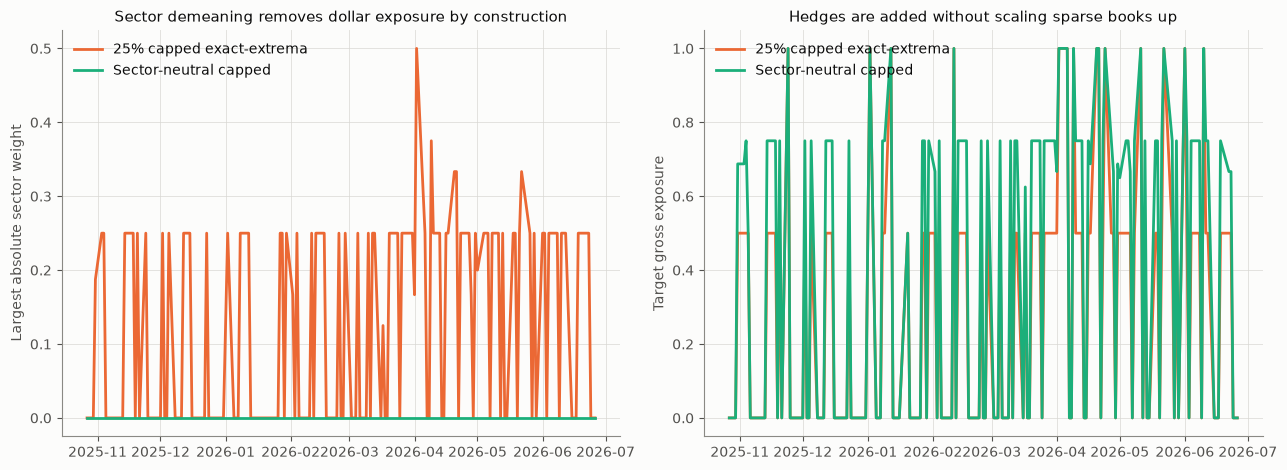

In [10]:
labels = {
    "capacity_capped": "25% capped exact-extrema",
    "sector_neutral": "Sector-neutral capped",
}
colours = {"capacity_capped": CATEGORICAL[1], "sector_neutral": CATEGORICAL[2]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    neutral_audit["session_date"],
    neutral_audit["base_max_abs_sector_exposure"],
    color=colours["capacity_capped"],
    label=labels["capacity_capped"],
)
axes[0].plot(
    neutral_audit["session_date"],
    neutral_audit["neutral_max_abs_sector_exposure"],
    color=colours["sector_neutral"],
    label=labels["sector_neutral"],
)
axes[0].set_ylabel("Largest absolute sector weight")
axes[0].set_title("Sector demeaning removes dollar exposure by construction")
axes[0].legend(loc="upper left")
axes[1].plot(
    capped_audit["session_date"],
    capped_audit["gross_exposure"],
    color=colours["capacity_capped"],
    label=labels["capacity_capped"],
)
axes[1].plot(
    neutral_audit["session_date"],
    neutral_audit["neutral_gross_exposure"],
    color=colours["sector_neutral"],
    label=labels["sector_neutral"],
)
axes[1].set_ylabel("Target gross exposure")
axes[1].set_title("Hedges are added without scaling sparse books up")
axes[1].legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "construction_and_sector_exposure.png", dpi=170, bbox_inches="tight")
plt.show()

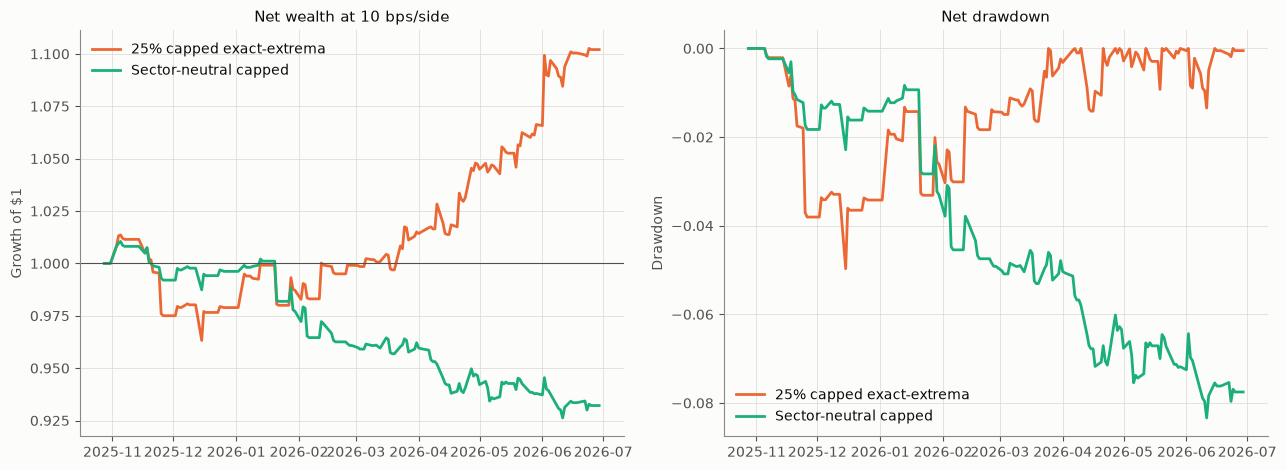

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm in ARMS:
    daily = daily_paths[arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[1:] - 1.0
    axes[0].plot(daily["return_end_date"], equity, color=colours[arm], label=labels[arm])
    axes[1].plot(daily["return_end_date"], drawdown, color=colours[arm], label=labels[arm])
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[1].set_ylabel("Drawdown")
axes[1].set_title("Net drawdown")
axes[0].legend(loc="best")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

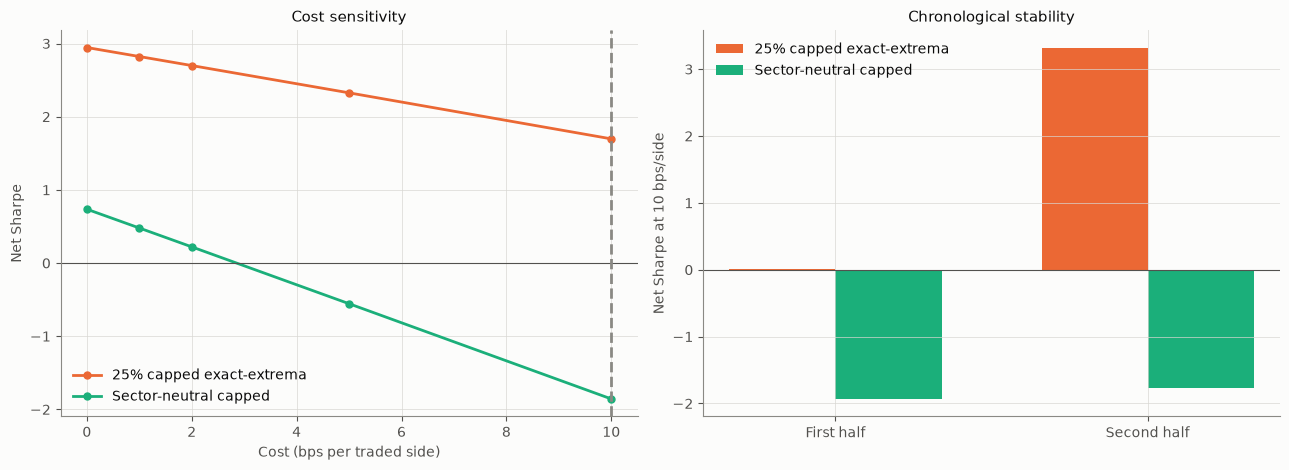

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm in ARMS:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[0].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[0].set_xlabel("Cost (bps per traded side)")
axes[0].set_ylabel("Net Sharpe")
axes[0].set_title("Cost sensitivity")
axes[0].legend(loc="best")
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(ARMS):
    axes[1].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Chronological stability")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "cost_and_temporal_stability.png", dpi=170, bbox_inches="tight")
plt.show()

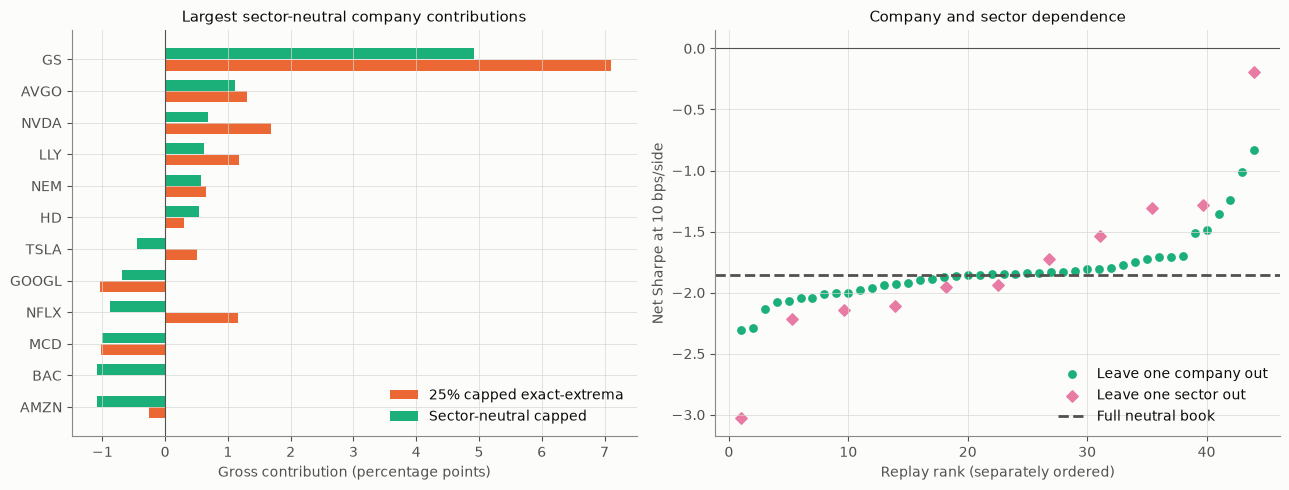

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
top_symbols = attribution.head(12)["symbol"].tolist()
top = attribution.loc[attribution["symbol"].isin(top_symbols)].copy()
top = top.sort_values("sector_neutral_gross_contribution")
y = np.arange(len(top))
axes[0].barh(
    y - 0.18,
    top["capacity_capped_gross_contribution"] * 100,
    height=0.34,
    color=colours["capacity_capped"],
    label=labels["capacity_capped"],
)
axes[0].barh(
    y + 0.18,
    top["sector_neutral_gross_contribution"] * 100,
    height=0.34,
    color=colours["sector_neutral"],
    label=labels["sector_neutral"],
)
axes[0].set_yticks(y, top["symbol"])
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xlabel("Gross contribution (percentage points)")
axes[0].set_title("Largest sector-neutral company contributions")
axes[0].legend(loc="best")
axes[1].scatter(
    np.arange(1, len(leave_one_out) + 1),
    leave_one_out["sharpe_net"],
    color=colours["sector_neutral"],
    s=28,
    label="Leave one company out",
)
axes[1].scatter(
    np.linspace(1, len(leave_one_out), len(leave_one_sector)),
    leave_one_sector["sharpe_net"],
    color=CATEGORICAL[4],
    marker="D",
    s=34,
    label="Leave one sector out",
)
axes[1].axhline(float(neutral["sharpe_net"]), color=INK["reference"], linestyle="--", label="Full neutral book")
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Replay rank (separately ordered)")
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Company and sector dependence")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "attribution_and_leave_one_out.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [14]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
candidate_feasibility.to_csv(OUTPUT_DIR / "candidate_feasibility.csv", index=False)
construction_audit.to_csv(OUTPUT_DIR / "construction_audit.csv", index=False)
capped_audit.to_csv(OUTPUT_DIR / "capped_target_audit.csv", index=False)
neutral_audit.to_csv(OUTPUT_DIR / "sector_neutral_target_audit.csv", index=False)
reproduction.to_csv(OUTPUT_DIR / "notebook30_reproduction.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
mechanism_decomposition.to_csv(OUTPUT_DIR / "mechanism_decomposition.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
neutral_vs_cash.to_csv(OUTPUT_DIR / "neutral_vs_cash.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
factor_exposure.to_csv(OUTPUT_DIR / "factor_exposure.csv", index=False)
attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
leave_one_out.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
leave_one_sector.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence_summary.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm in ARMS:
    daily_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)
    ledger_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_ledger.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_ITERATIVE_NON_POOLED_LSEG_FACTOR_CONTROL_AUDIT",
    "notebook": "31_lseg_gemma_sector_neutral_extrema_spread.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "notebook30_manifest": str(NOTEBOOK30_MANIFEST.relative_to(REPO_ROOT)),
        "price_paths": [str(path.relative_to(REPO_ROOT)) for path in PRICE_PATHS],
        "earnings_date_only_path": str(EARNINGS_PATH.relative_to(REPO_ROOT)),
        "licensed_headline_text_loaded": False,
        "licensed_earnings_title_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "candidate_feasibility": json.loads(candidate_feasibility.to_json(orient="records")),
    "specification": {
        "signal": "unchanged Gemma strongest_event exact +1/-1",
        "baseline": "Notebook 30 capacity-capped exact-extrema spread",
        "sector_map": "frozen 11 sectors x 4 companies",
        "sector_neutralization": "subtract equal-weight within-sector mean target",
        "post_demean_scaling": "one common scale down only",
        "single_name_cap": SINGLE_NAME_CAP,
        "gross_limit": GROSS_EXPOSURE,
        "same_active_sessions_as_baseline": True,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "drifted_weights_marked_against_after_cost_nav": True,
        "final_liquidation": True,
    },
    "construction_audit": json.loads(construction_audit.to_json(orient="records"))[0],
    "notebook30_reproduction": json.loads(reproduction.to_json(orient="records"))[0],
    "results": json.loads(results.to_json(orient="records")),
    "mechanism_decomposition": json.loads(
        mechanism_decomposition.to_json(orient="records")
    )[0],
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "neutral_vs_cash": json.loads(neutral_vs_cash.to_json(orient="records"))[0],
    "temporal": json.loads(temporal.to_json(orient="records")),
    "factor_exposure": json.loads(factor_exposure.to_json(orient="records")),
    "dependence": json.loads(dependence_summary.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "Notebook 30 results motivated this factor-control audit on the same opened window",
        "the sector map and 25% cap were frozen upstream rather than selected here",
        "sector demeaning creates mechanical hedge positions in zero-signal peers",
        "sector dollar neutrality does not prove market-beta or style-factor neutrality",
        "the eight-month LSEG snapshot is not a pristine confirmatory holdout",
        "the local earnings calendar has no date overlap with this 2025-2026 panel",
        "human validation of full-corpus Gemma sentiment remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_ITERATIVE_NON_POOLED_LSEG_FACTOR_CONTROL_AUDIT",
  "notebook": "31_lseg_gemma_sector_neutral_extrema_spread.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260806,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "notebook30_manifest": "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread/manifest.json",
    "price_paths": [
      "Data/derived/prices/lseg_us_sector_33_8m.csv",
      "Data/derived/prices/lseg_us_sector_add11_8m.csv"
    ],
    "earnings_date_only_path": "final_experiments/data/earnings/fnspid_earnings_calendar_2011_2023_quarterly.csv",
    "licensed_headline_text_loaded": false,
    "licensed_earnings_title_loaded": false
  },
  "coverage": {
    "firm_open_rows": 7348,
    "sessions": 167,
    "companies": 44,
    "sectors": 11,
    "first_entry_session": "2025-10-27T00:00:00.000",
    "last_e

## Decision

**All four gates fail.** Sector demeaning achieves its mechanical objective:
maximum absolute sector weight falls from **50% to numerical zero**, maximum
name weight remains **25%**, and equal-weight-market beta falls from **0.100
to 0.031**. But it destroys the strategy result. At 10 bps per side, net
Sharpe falls from **1.697 to -1.857**, net return from **+10.20% to -6.78%**,
maximum drawdown worsens from **-4.97% to -8.34%**, and break-even falls from
**23.24 to 2.85 bps/side**.

The sector-neutral-minus-capped mean is **-10.118 bps per session** (95%
block-bootstrap CI **[-15.491, -4.902] bps**, BH-adjusted p = **0.0004**).
Downside-squared loss does not improve (p = **0.521**), and the cash interval
still crosses zero. Net Sharpe is negative in both chronological halves
(**-1.932**, **-1.775**); all 44 leave-one-company-out and all 11
leave-one-sector-out replays also lose money after costs.

This is not merely a trading-cost failure. The mean gap decomposes into
**-8.832 bps/session of gross return** and **-1.286 bps/session of incremental
cost**: **87.3%** of the net deterioration comes from removing gross return,
while 12.7% comes from the wider hedge book. The useful result is therefore a
mechanism boundary: the capped Gemma spread is not a within-sector stock-
selection strategy. Its positive result is primarily carried by between-
sector allocation. Retain Notebook 30 as the frozen independent-date
candidate. Notebook 32 subsequently records the exact complementary sector
projection as an explicitly retrospective secondary mechanism test; it does
not retroactively change any gate here.